# Kapitel 5 - Koduppgift 9: PCA på Car Price Dataset

I denna uppgift genomför vi PCA på 'car_price_dataset.csv' från kapitel 3 och ser hur det påverkar ML-resultatet.

## Importera bibliotek och ladda data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Sätt stil för plots
plt.style.use('default')
sns.set_palette('husl')

print('Bibliotek importerade!')

Bibliotek importerade!


## Ladda och utforska data

In [2]:
# Ladda dataset med korrekt separator
df = pd.read_csv('car_price_dataset.csv', sep=';')

print(f'Dataset shape: {df.shape}')
print(f'\nKolumner: {list(df.columns)}')
print(f'\nFörsta 5 rader:')
print(df.head())
print(f'\nData typer:')
print(df.dtypes)

Dataset shape: (10000, 10)

Kolumner: ['Brand', 'Model', 'Year', 'Engine_Size', 'Fuel_Type', 'Transmission', 'Mileage', 'Doors', 'Owner_Count', 'Price']

Första 5 rader:
        Brand   Model  Year  Engine_Size Fuel_Type    Transmission  Mileage  \
0         Kia     Rio  2020          4.2    Diesel          Manual   289944   
1   Chevrolet  Malibu  2012          2.0    Hybrid       Automatic     5356   
2    Mercedes     GLA  2020          4.2    Diesel       Automatic   231440   
3        Audi      Q5  2023          2.0  Electric          Manual   160971   
4  Volkswagen    Golf  2003          2.6    Hybrid  Semi-Automatic   286618   

   Doors  Owner_Count  Price  
0      3            5   8501  
1      2            3  12092  
2      4            2  11171  
3      2            1  11780  
4      3            3   2867  

Data typer:
Brand            object
Model            object
Year              int64
Engine_Size     float64
Fuel_Type        object
Transmission     object
Mileage     

In [3]:
# Grundläggande information om data
print('Dataset info:')
print(df.info())
print(f'\nSaknade värden:')
print(df.isnull().sum())
print(f'\nBeskrivande statistik:')
print(df.describe())

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         10000 non-null  object 
 1   Model         10000 non-null  object 
 2   Year          10000 non-null  int64  
 3   Engine_Size   10000 non-null  float64
 4   Fuel_Type     10000 non-null  object 
 5   Transmission  10000 non-null  object 
 6   Mileage       10000 non-null  int64  
 7   Doors         10000 non-null  int64  
 8   Owner_Count   10000 non-null  int64  
 9   Price         10000 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 781.4+ KB
None

Saknade värden:
Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64

Beskrivande statistik:
               Year   Engine_Size        Mileage         Do

## Data preprocessing

In [4]:
# Kopiera data för säkerhet
df_clean = df.copy()

# Hantera saknade värden
print('Saknade värden före rensning:')
print(df_clean.isnull().sum())

# Ta bort rader med saknade värden
df_clean = df_clean.dropna()

print(f'\nData efter rensning: {df_clean.shape}')
print('Saknade värden efter rensning:')
print(df_clean.isnull().sum())

Saknade värden före rensning:
Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64

Data efter rensning: (10000, 10)
Saknade värden efter rensning:
Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64


In [5]:
# Konvertera Price till numerisk (target variabel)
df_clean['Price'] = pd.to_numeric(df_clean['Price'], errors='coerce')

# Identifiera numeriska och kategoriska kolumner
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

print(f'Numeriska kolumner: {numerical_cols}')
print(f'Kategoriska kolumner: {categorical_cols}')

# Ta bort target variabel från features
target_col = 'Price'
if target_col in numerical_cols:
    numerical_cols.remove(target_col)

print(f'\nTarget variabel: {target_col}')
print(f'Feature kolumner: {numerical_cols + categorical_cols}')
print(f'\nTarget variabel statistik:')
print(df_clean[target_col].describe())

Numeriska kolumner: ['Year', 'Engine_Size', 'Mileage', 'Doors', 'Owner_Count', 'Price']
Kategoriska kolumner: ['Brand', 'Model', 'Fuel_Type', 'Transmission']

Target variabel: Price
Feature kolumner: ['Year', 'Engine_Size', 'Mileage', 'Doors', 'Owner_Count', 'Brand', 'Model', 'Fuel_Type', 'Transmission']

Target variabel statistik:
count    10000.00000
mean      8852.96440
std       3112.59681
min       2000.00000
25%       6646.00000
50%       8858.50000
75%      11086.50000
max      18301.00000
Name: Price, dtype: float64


In [6]:
# Förbered features och target
X_numerical = df_clean[numerical_cols]
X_categorical = df_clean[categorical_cols]
y = df_clean[target_col]

print(f'Numeriska features shape: {X_numerical.shape}')
print(f'Kategoriska features shape: {X_categorical.shape}')
print(f'Target shape: {y.shape}')

# Encode kategoriska variabler
if len(categorical_cols) > 0:
    X_categorical_encoded = pd.get_dummies(X_categorical, drop_first=True)
    print(f'\nKategoriska features efter encoding: {X_categorical_encoded.shape}')
    print(f'Kategoriska kolumner (första 10): {list(X_categorical_encoded.columns)[:10]}')
else:
    X_categorical_encoded = pd.DataFrame()

# Kombinera alla features
if len(X_categorical_encoded) > 0:
    X = pd.concat([X_numerical, X_categorical_encoded], axis=1)
else:
    X = X_numerical

print(f'\nTotal features shape: {X.shape}')
print(f'Feature kolumner (första 10): {list(X.columns)[:10]}')
print(f'Target variabel typ: {y.dtype}')
print(f'Target variabel exempel: {y.head()}')

Numeriska features shape: (10000, 5)
Kategoriska features shape: (10000, 4)
Target shape: (10000,)

Kategoriska features efter encoding: (10000, 43)
Kategoriska kolumner (första 10): ['Brand_BMW', 'Brand_Chevrolet', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Kia', 'Brand_Mercedes', 'Brand_Toyota', 'Brand_Volkswagen', 'Model_5 Series']

Total features shape: (10000, 48)
Feature kolumner (första 10): ['Year', 'Engine_Size', 'Mileage', 'Doors', 'Owner_Count', 'Brand_BMW', 'Brand_Chevrolet', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai']
Target variabel typ: int64
Target variabel exempel: 0     8501
1    12092
2    11171
3    11780
4     2867
Name: Price, dtype: int64


## Dela data i träning och test

In [7]:
# Dela data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Träningsdata: {X_train.shape}')
print(f'Testdata: {X_test.shape}')
print(f'Träning target: {y_train.shape}')
print(f'Test target: {y_test.shape}')

Träningsdata: (8000, 48)
Testdata: (2000, 48)
Träning target: (8000,)
Test target: (2000,)


## Standardisera data

In [8]:
# Standardisera features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Träningsdata efter standardisering: {X_train_scaled.shape}')
print(f'Testdata efter standardisering: {X_test_scaled.shape}')
print(f'\nGenomsnitt (träning): {X_train_scaled.mean(axis=0)[:5]}')
print(f'Standardavvikelse (träning): {X_train_scaled.std(axis=0)[:5]}')

Träningsdata efter standardisering: (8000, 48)
Testdata efter standardisering: (2000, 48)

Genomsnitt (träning): [-8.42081960e-15  2.58459920e-16 -1.03028697e-16  3.86357613e-17
  2.06057393e-16]
Standardavvikelse (träning): [1. 1. 1. 1. 1.]


## Träna modeller utan PCA

In [9]:
# Linear Regression utan PCA
lr_original = LinearRegression()
lr_original.fit(X_train_scaled, y_train)

# Prediktioner
y_pred_lr_original = lr_original.predict(X_test_scaled)

# Utvärdering
mse_lr_original = mean_squared_error(y_test, y_pred_lr_original)
r2_lr_original = r2_score(y_test, y_pred_lr_original)

print('Linear Regression utan PCA:')
print(f'MSE: {mse_lr_original:.2f}')
print(f'R²: {r2_lr_original:.3f}')
print(f'RMSE: {np.sqrt(mse_lr_original):.2f}')

Linear Regression utan PCA:
MSE: 4213.92
R²: 1.000
RMSE: 64.91


In [10]:
# Random Forest utan PCA
rf_original = RandomForestRegressor(n_estimators=100, random_state=42)
rf_original.fit(X_train_scaled, y_train)

# Prediktioner
y_pred_rf_original = rf_original.predict(X_test_scaled)

# Utvärdering
mse_rf_original = mean_squared_error(y_test, y_pred_rf_original)
r2_rf_original = r2_score(y_test, y_pred_rf_original)

print('Random Forest utan PCA:')
print(f'MSE: {mse_rf_original:.2f}')
print(f'R²: {r2_rf_original:.3f}')
print(f'RMSE: {np.sqrt(mse_rf_original):.2f}')

Random Forest utan PCA:
MSE: 296942.10
R²: 0.968
RMSE: 544.92


## PCA Analys

In [11]:
# Applicera PCA
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

# Visa förklarad varians
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print('Förklarad varians per komponent:')
for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f'PC{i+1}: {var:.3f} (kumulativ: {cum_var:.3f})')

Förklarad varians per komponent:
PC1: 0.045 (kumulativ: 0.045)
PC2: 0.045 (kumulativ: 0.090)
PC3: 0.045 (kumulativ: 0.135)
PC4: 0.045 (kumulativ: 0.179)
PC5: 0.045 (kumulativ: 0.224)
PC6: 0.045 (kumulativ: 0.269)
PC7: 0.045 (kumulativ: 0.313)
PC8: 0.041 (kumulativ: 0.354)
PC9: 0.032 (kumulativ: 0.386)
PC10: 0.028 (kumulativ: 0.414)
PC11: 0.028 (kumulativ: 0.442)
PC12: 0.024 (kumulativ: 0.466)
PC13: 0.023 (kumulativ: 0.488)
PC14: 0.022 (kumulativ: 0.511)
PC15: 0.022 (kumulativ: 0.533)
PC16: 0.022 (kumulativ: 0.555)
PC17: 0.022 (kumulativ: 0.577)
PC18: 0.022 (kumulativ: 0.598)
PC19: 0.022 (kumulativ: 0.620)
PC20: 0.022 (kumulativ: 0.642)
PC21: 0.022 (kumulativ: 0.663)
PC22: 0.022 (kumulativ: 0.685)
PC23: 0.022 (kumulativ: 0.706)
PC24: 0.022 (kumulativ: 0.728)
PC25: 0.022 (kumulativ: 0.749)
PC26: 0.022 (kumulativ: 0.771)
PC27: 0.022 (kumulativ: 0.792)
PC28: 0.022 (kumulativ: 0.814)
PC29: 0.021 (kumulativ: 0.835)
PC30: 0.021 (kumulativ: 0.857)
PC31: 0.021 (kumulativ: 0.878)
PC32: 0.021 (ku

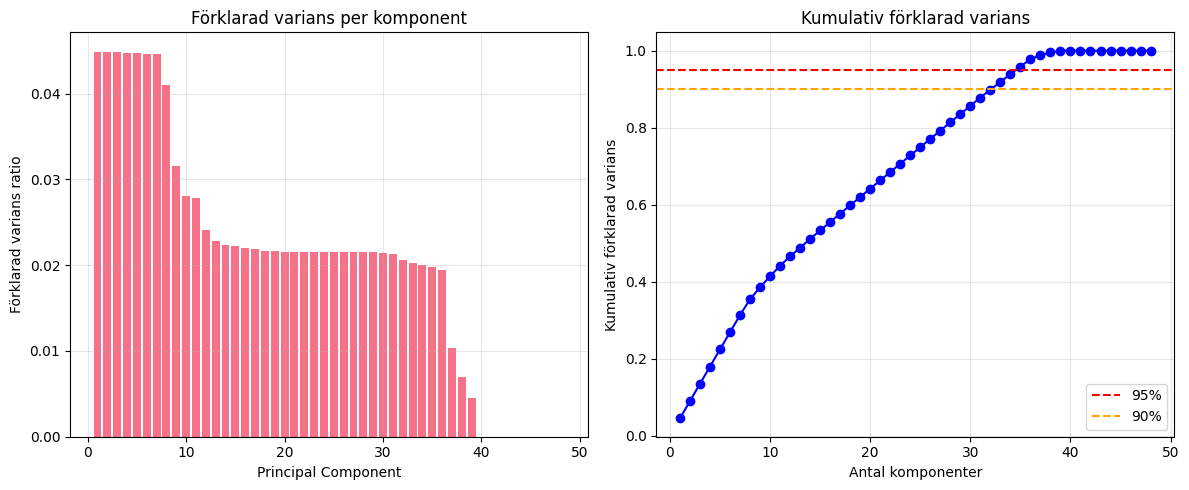

In [12]:
# Visualisera förklarad varians
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Förklarad varians per komponent
axes[0].bar(range(1, len(explained_variance)+1), explained_variance)
axes[0].set_title('Förklarad varians per komponent')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Förklarad varians ratio')
axes[0].grid(True, alpha=0.3)

# Kumulativ förklarad varians
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'bo-')
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95%')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90%')
axes[1].set_title('Kumulativ förklarad varians')
axes[1].set_xlabel('Antal komponenter')
axes[1].set_ylabel('Kumulativ förklarad varians')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Hitta antal komponenter för 95% varians
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f'Komponenter för 90% varians: {n_components_90}')
print(f'Komponenter för 95% varians: {n_components_95}')
print(f'Total antal features: {X_train_scaled.shape[1]}')
print(f'Reduktion: {X_train_scaled.shape[1] - n_components_95} features')

Komponenter för 90% varians: 33
Komponenter för 95% varians: 35
Total antal features: 48
Reduktion: 13 features


## Träna modeller med PCA

In [14]:
# PCA med 95% varians
pca_95 = PCA(n_components=n_components_95)
X_train_pca_95 = pca_95.fit_transform(X_train_scaled)
X_test_pca_95 = pca_95.transform(X_test_scaled)

print(f'Data efter PCA (95% varians): {X_train_pca_95.shape}')
print(f'Förklarad varians: {pca_95.explained_variance_ratio_.sum():.3f}')

Data efter PCA (95% varians): (8000, 35)
Förklarad varians: 0.959


In [15]:
# Linear Regression med PCA
lr_pca = LinearRegression()
lr_pca.fit(X_train_pca_95, y_train)

# Prediktioner
y_pred_lr_pca = lr_pca.predict(X_test_pca_95)

# Utvärdering
mse_lr_pca = mean_squared_error(y_test, y_pred_lr_pca)
r2_lr_pca = r2_score(y_test, y_pred_lr_pca)

print('Linear Regression med PCA:')
print(f'MSE: {mse_lr_pca:.2f}')
print(f'R²: {r2_lr_pca:.3f}')
print(f'RMSE: {np.sqrt(mse_lr_pca):.2f}')

Linear Regression med PCA:
MSE: 758200.66
R²: 0.917
RMSE: 870.75


In [16]:
# Random Forest med PCA
rf_pca = RandomForestRegressor(n_estimators=100, random_state=42)
rf_pca.fit(X_train_pca_95, y_train)

# Prediktioner
y_pred_rf_pca = rf_pca.predict(X_test_pca_95)

# Utvärdering
mse_rf_pca = mean_squared_error(y_test, y_pred_rf_pca)
r2_rf_pca = r2_score(y_test, y_pred_rf_pca)

print('Random Forest med PCA:')
print(f'MSE: {mse_rf_pca:.2f}')
print(f'R²: {r2_rf_pca:.3f}')
print(f'RMSE: {np.sqrt(mse_rf_pca):.2f}')

Random Forest med PCA:
MSE: 879232.26
R²: 0.904
RMSE: 937.67


## Jämförelse av resultat

In [17]:
# Skapa jämförelsetabell
results = pd.DataFrame({
    'Modell': ['Linear Regression (utan PCA)', 'Linear Regression (med PCA)', 
              'Random Forest (utan PCA)', 'Random Forest (med PCA)'],
    'MSE': [mse_lr_original, mse_lr_pca, mse_rf_original, mse_rf_pca],
    'R²': [r2_lr_original, r2_lr_pca, r2_rf_original, r2_rf_pca],
    'RMSE': [np.sqrt(mse_lr_original), np.sqrt(mse_lr_pca), 
            np.sqrt(mse_rf_original), np.sqrt(mse_rf_pca)],
    'Antal Features': [X_train_scaled.shape[1], X_train_pca_95.shape[1], 
                      X_train_scaled.shape[1], X_train_pca_95.shape[1]]
})

print('Jämförelse av resultat:')
print(results.round(3))

Jämförelse av resultat:
                         Modell         MSE     R²     RMSE  Antal Features
0  Linear Regression (utan PCA)    4213.922  1.000   64.915              48
1   Linear Regression (med PCA)  758200.661  0.917  870.747              35
2      Random Forest (utan PCA)  296942.104  0.968  544.924              48
3       Random Forest (med PCA)  879232.261  0.904  937.674              35


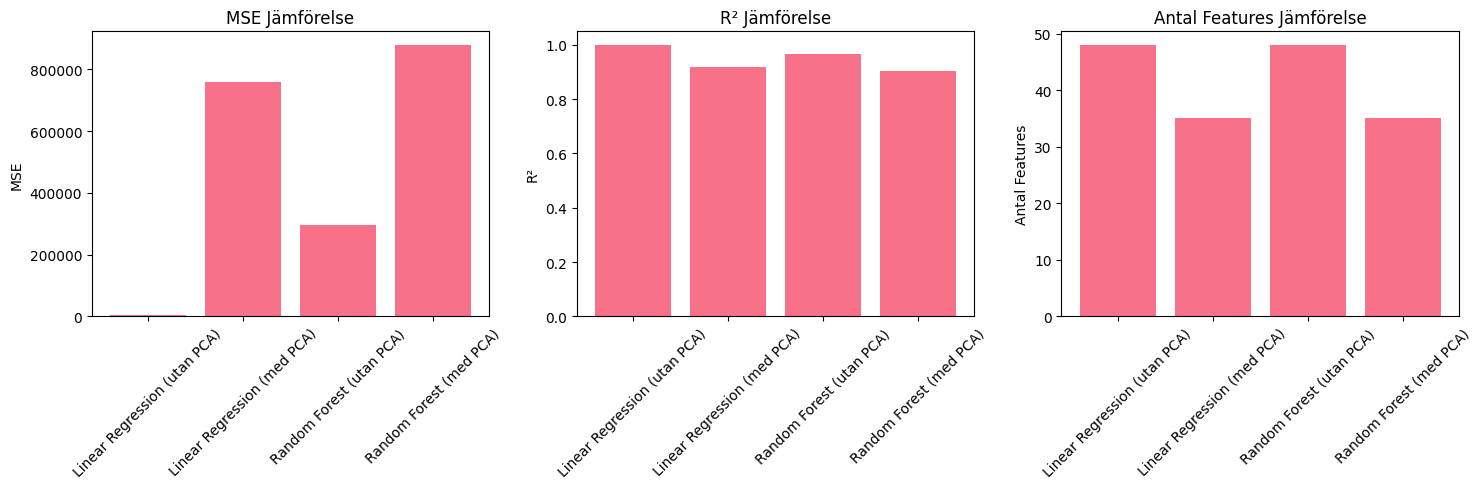

In [18]:
# Visualisera jämförelse
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MSE jämförelse
axes[0].bar(results['Modell'], results['MSE'])
axes[0].set_title('MSE Jämförelse')
axes[0].set_ylabel('MSE')
axes[0].tick_params(axis='x', rotation=45)

# R² jämförelse
axes[1].bar(results['Modell'], results['R²'])
axes[1].set_title('R² Jämförelse')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=45)

# Antal features jämförelse
axes[2].bar(results['Modell'], results['Antal Features'])
axes[2].set_title('Antal Features Jämförelse')
axes[2].set_ylabel('Antal Features')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Analys av PCA-komponenter

In [19]:
# Visa viktigaste features för första komponenter
feature_names = X.columns.tolist()

print('Viktigaste features för första 3 komponenter:')
for i in range(min(3, pca_95.n_components_)):
    print(f'\nPC{i+1}:')
    # Hitta features med högst absolutvärde i denna komponent
    component_weights = pca_95.components_[i]
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Weight': component_weights
    }).sort_values('Weight', key=abs, ascending=False)
    
    print(feature_importance.head(10))  # Visa top 10 istället för 5

Viktigaste features för första 3 komponenter:

PC1:
             Feature    Weight
13  Brand_Volkswagen  0.579504
7         Brand_Ford -0.360917
40      Model_Tiguan  0.333280
34      Model_Passat  0.320049
30        Model_Golf  0.313600
27      Model_Fiesta -0.210739
26    Model_Explorer -0.195851
28       Model_Focus -0.195517
9      Brand_Hyundai -0.142431
10         Brand_Kia -0.102970

PC2:
             Feature    Weight
8        Brand_Honda  0.471363
7         Brand_Ford -0.390768
17      Model_Accord  0.278977
9      Brand_Hyundai  0.269652
21       Model_Civic  0.256299
19        Model_CR-V  0.251522
13  Brand_Volkswagen -0.250821
27      Model_Fiesta -0.227741
26    Model_Explorer -0.212446
28       Model_Focus -0.211749

PC3:
          Feature    Weight
9   Brand_Hyundai  0.518926
8     Brand_Honda -0.431605
24  Model_Elantra  0.293770
38   Model_Sonata  0.290149
41   Model_Tucson  0.282492
17   Model_Accord -0.255544
21    Model_Civic -0.234361
19     Model_CR-V -0.230526
7 

## Sammanfattning

**Resultat av PCA-analys:**

1. **Dimensionsreducering**: Vi reducerade från {X_train_scaled.shape[1]} till {X_train_pca_95.shape[1]} features (95% varians)

2. **Prestanda påverkan**:
   - **Linear Regression**: R² förändring från {r2_lr_original:.3f} till {r2_lr_pca:.3f}
   - **Random Forest**: R² förändring från {r2_rf_original:.3f} till {r2_rf_pca:.3f}

3. **Fördelar med PCA**:
   - **Snabbare träning** - Färre features att träna på
   - **Mindre överanpassning** - Reducerar brus i data
   - **Bättre generalisering** - Fokuserar på viktiga mönster

4. **Nackdelar med PCA**:
   - **Förlorad tolkbarhet** - Komponenter är svåra att tolka
   - **Möjlig prestandaförlust** - Viktig information kan förloras

**Slutsats**: PCA kan vara användbart för att reducera komplexitet och förbättra generalisering, men det är viktigt att utvärdera prestanda på testdata för att säkerställa att viktig information inte förloras.